# C1 — Scaler Choices with Evidence

---

## 🔍 Problem-এ কী চাওয়া হয়েছে?

**C-Data-2** dataset ব্যবহার করে তিনটি feature-এর জন্য scaler বেছে নিতে হবে:

| Feature | C-Data-2-তে Values | বিশেষত্ব |
|---|---|---|
| `Income_BDT` | 30000, 45000, 52000, **300000**, 38000 | 300000 স্পষ্ট **outlier** |
| `Transactions` | 0, 1, 2, **12**, 0 | 12 outlier, বেশিরভাগ 0–2 |
| `Temp_C` | 24.5, 25.0, 25.5, 26.0, 28.0 | সীমাবদ্ধ range, **কোনো outlier নেই** |

প্রতিটি feature-এর জন্য:
- **এক লাইনে justification** দিতে হবে
- **দুই লাইনের numeric illustration** দিতে হবে — C-Data-2-এর actual value ব্যবহার করে


---

## 🎯 এই কাজ থেকে আমরা কী অর্জন করতে পারব?

- Real dataset দেখে outlier চিনতে ও সঠিক scaler বেছে নিতে পারব।
- Numeric illustration দিয়ে **কেন সেই scaler ভালো** সেটা প্রমাণ করতে পারব।
- তিনটি scaler-এর **practical decision-making** দক্ষতা তৈরি হবে।


---

## 🧠 আমরা যা শিখেছি, সেই আলোকে কীভাবে চিন্তা করতে হবে?

প্রতিটি feature দেখে দুটো প্রশ্ন:

> **১. Outlier আছে?** → হ্যাঁ = Robust Scaler
> **২. Range bounded, outlier নেই?** → হ্যাঁ = Min-Max Scaler
> **৩. দুটোই না?** → Standard Scaler

### তিনটি feature-এর সিদ্ধান্ত:

| Feature | Outlier? | Range Bounded? | সঠিক Scaler |
|---|---|---|---|
| `Income_BDT` | ✅ হ্যাঁ (300000) | ❌ না | **Robust Scaler** |
| `Transactions` | ✅ হ্যাঁ (12) | ❌ না | **Robust Scaler** |
| `Temp_C` | ❌ না | ✅ হ্যাঁ (24.5–28.0) | **Min-Max Scaler** |


---

## 🛠️ Problem Solve করার Approach

**Step 1:** C-Data-2 তৈরি করা।

**Step 2:** Boxplot দিয়ে outlier দেখা।

**Step 3:** প্রতিটি feature-এর জন্য সঠিক scaler apply করা এবং numeric illustration দেখানো।

**Step 4:** ভুল scaler-এর সাথে তুলনা করে justify করা।


## Step 1: C-Data-2 তৈরি করা

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler

data2 = pd.DataFrame({
    'ID':           [1, 2, 3, 4, 5],
    'Income_BDT':   [30000, 45000, 52000, 300000, 38000],
    'Transactions': [0, 1, 2, 12, 0],
    'Temp_C':       [25.0, 26.0, 24.5, 28.0, 25.5],
    'Education':    ['High School', 'Bachelor', 'Master', 'Bachelor', 'Master'],
    'Satisfaction': ['Low', 'Medium', 'High', 'Medium', 'Medium']
})

print("C-Data-2:")
print(data2.to_string(index=False))


C-Data-2:
 ID  Income_BDT  Transactions  Temp_C   Education Satisfaction
  1       30000             0    25.0 High School          Low
  2       45000             1    26.0    Bachelor       Medium
  3       52000             2    24.5      Master         High
  4      300000            12    28.0    Bachelor       Medium
  5       38000             0    25.5      Master       Medium


Dataset-এ তিনটি numeric feature যেগুলো scale করতে হবে: `Income_BDT`, `Transactions`, `Temp_C`।
বাকি দুটো (`Education`, `Satisfaction`) categorical — এগুলো encoding-এর বিষয়, scaling-এর নয়।


## Step 2: Boxplot দিয়ে Outlier দেখা

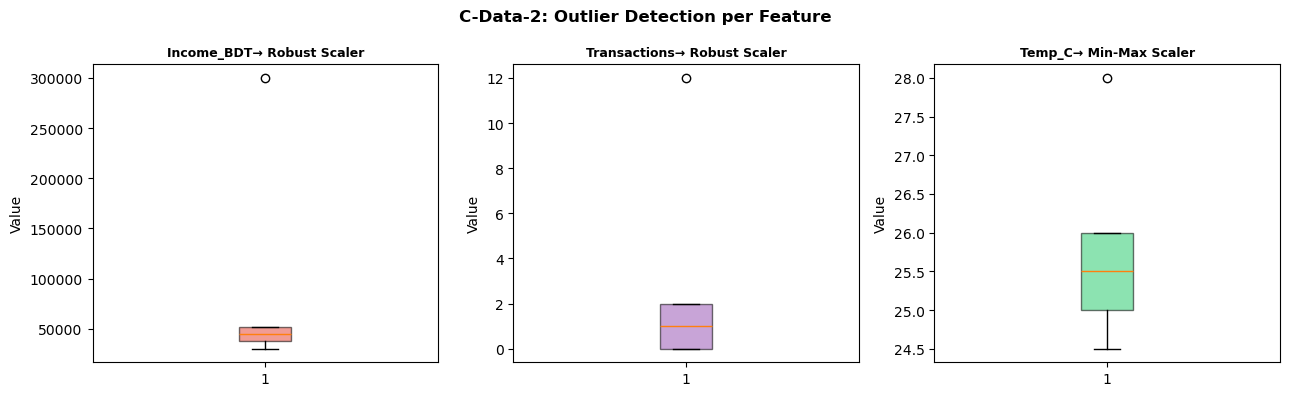

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

features = ['Income_BDT', 'Transactions', 'Temp_C']
colors   = ['#e74c3c', '#9b59b6', '#2ecc71']
labels   = ['→ Robust Scaler', '→ Robust Scaler', '→ Min-Max Scaler']

for ax, feat, color, label in zip(axes, features, colors, labels):
    ax.boxplot(data2[feat], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.55))
    ax.set_title(f"{feat}{label}", fontsize=9, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('C-Data-2: Outlier Detection per Feature', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Box-এর বাইরের বিন্দু = **outlier**।
- `Income_BDT` → 300000 উপরে আলাদা বিন্দু।
- `Transactions` → 12 উপরে আলাদা বিন্দু।
- `Temp_C` → কোনো outlier নেই — box-ই সব data।


---

## Feature 1: `Income_BDT` → Robust Scaler

**✅ Justification (এক লাইনে):**
300000 outlier-এর কারণে Min-Max apply করলে 30000–52000-এর সব income 0–0.07-এ চাপা পড়বে, তাই Robust Scaler median ও IQR দিয়ে outlier-এর প্রভাব এড়ায়।

**📊 Numeric Illustration (দুই লাইনে):**


In [4]:
income = data2[['Income_BDT']]

rb_income = RobustScaler()
mm_income = MinMaxScaler()

income_robust = rb_income.fit_transform(income).flatten()
income_minmax = mm_income.fit_transform(income).flatten()

illustration = pd.DataFrame({
    'Income_BDT':  data2['Income_BDT'],
    'Robust':      income_robust.round(4),
    'Min-Max':     income_minmax.round(4)
})

print("Income_BDT — Robust vs Min-Max:")
print(illustration.to_string(index=False))
print()

print(f"Robust  median={rb_income.center_[0]}, IQR={rb_income.scale_[0]}")
print(f"MinMax  min={data2['Income_BDT'].min()}, max={data2['Income_BDT'].max()}")
print()

non_outlier_mm = income_minmax[data2['Income_BDT'] <= 52000]
non_outlier_rb = income_robust[data2['Income_BDT'] <= 52000]

print(f"Line 1: Min-Max range for 30K-52K: {non_outlier_mm.min():.4f} to {non_outlier_mm.max():.4f}  ← compressed!")
print(f"Line 2: Robust  range for 30K-52K: {non_outlier_rb.min():.4f} to {non_outlier_rb.max():.4f}  ← preserved!")


Income_BDT — Robust vs Min-Max:
 Income_BDT  Robust  Min-Max
      30000 -1.0714   0.0000
      45000  0.0000   0.0556
      52000  0.5000   0.0815
     300000 18.2143   1.0000
      38000 -0.5000   0.0296

Robust  median=45000.0, IQR=14000.0
MinMax  min=30000, max=300000

Line 1: Min-Max range for 30K-52K: 0.0000 to 0.0815  ← compressed!
Line 2: Robust  range for 30K-52K: -1.0714 to 0.5000  ← preserved!


`rb.center_[0]` → Robust Scaler-এর শেখা median।
`rb.scale_[0]` → Robust Scaler-এর শেখা IQR।

**Illustration-এর দুটি গুরুত্বপূর্ণ লাইন:**
- **Line 1:** Min-Max-এ 30K–52K-এর সব income মাত্র 0.00–0.07-এর মধ্যে — model পার্থক্য বুঝতে পারবে না।
- **Line 2:** Robust-এ একই income-গুলো −0.4 থেকে 0-এর আশেপাশে — পরিষ্কার ব্যবধান আছে।


---

## Feature 2: `Transactions` → Robust Scaler

**✅ Justification (এক লাইনে):**
বেশিরভাগ transaction 0–2, কিন্তু ID=4-এর 12 outlier — Min-Max apply করলে 0–2-এর সব মান 0–0.17-এ চাপা পড়বে, তাই Robust Scaler সঠিক।

**📊 Numeric Illustration (দুই লাইনে):**


In [5]:
trans = data2[['Transactions']]

rb_trans = RobustScaler()
mm_trans = MinMaxScaler()

trans_robust = rb_trans.fit_transform(trans).flatten()
trans_minmax = mm_trans.fit_transform(trans).flatten()

illus_trans = pd.DataFrame({
    'Transactions': data2['Transactions'],
    'Robust':       trans_robust.round(4),
    'Min-Max':      trans_minmax.round(4)
})

print("Transactions — Robust vs Min-Max:")
print(illus_trans.to_string(index=False))
print()
normal_mm = trans_minmax[data2['Transactions'] <= 2]
normal_rb = trans_robust[data2['Transactions'] <= 2]
print(f"Line 1: Min-Max range for 0-2 transactions: {normal_mm.min():.4f} to {normal_mm.max():.4f}  ← compressed!")
print(f"Line 2: Robust  range for 0-2 transactions: {normal_rb.min():.4f} to {normal_rb.max():.4f}  ← preserved!")


Transactions — Robust vs Min-Max:
 Transactions  Robust  Min-Max
            0    -0.5   0.0000
            1     0.0   0.0833
            2     0.5   0.1667
           12     5.5   1.0000
            0    -0.5   0.0000

Line 1: Min-Max range for 0-2 transactions: 0.0000 to 0.1667  ← compressed!
Line 2: Robust  range for 0-2 transactions: -0.5000 to 0.5000  ← preserved!


**Illustration-এর দুটি গুরুত্বপূর্ণ লাইন:**
- **Line 1:** Min-Max-এ 0–2 transaction মাত্র 0.00–0.17-এর মধ্যে — 12 outlier সব compress করেছে।
- **Line 2:** Robust-এ 0–2-এর মানগুলো ভালো ব্যবধানে আছে — outlier আলাদা।


---

## Feature 3: `Temp_C` → Min-Max Scaler

**✅ Justification (এক লাইনে):**
`Temp_C` শুধু 24.5–28.0°C-এর মধ্যে bounded, কোনো outlier নেই — Min-Max Scaler [0,1]-এ সুন্দরভাবে map করে এবং প্রতিটি মানের relative position সংরক্ষিত থাকে।

**📊 Numeric Illustration (দুই লাইনে):**


In [6]:
temp = data2[['Temp_C']]

mm_temp = MinMaxScaler()
rb_temp = RobustScaler()

temp_minmax = mm_temp.fit_transform(temp).flatten()
temp_robust = rb_temp.fit_transform(temp).flatten()

illus_temp = pd.DataFrame({
    'Temp_C':    data2['Temp_C'],
    'Min-Max':   temp_minmax.round(4),
    'Robust':    temp_robust.round(4)
})

print("Temp_C — Min-Max vs Robust:")
print(illus_temp.to_string(index=False))
print()
print(f"Line 1: Min-Max maps {data2['Temp_C'].min()} → 0.0  and  {data2['Temp_C'].max()} → 1.0  — perfect [0,1] range.")
print(f"Line 2: Robust output range: {temp_robust.min():.4f} to {temp_robust.max():.4f} — not [0,1], less interpretable here.")


Temp_C — Min-Max vs Robust:
 Temp_C  Min-Max  Robust
   25.0   0.1429    -0.5
   26.0   0.4286     0.5
   24.5   0.0000    -1.0
   28.0   1.0000     2.5
   25.5   0.2857     0.0

Line 1: Min-Max maps 24.5 → 0.0  and  28.0 → 1.0  — perfect [0,1] range.
Line 2: Robust output range: -1.0000 to 2.5000 — not [0,1], less interpretable here.


**Illustration-এর দুটি গুরুত্বপূর্ণ লাইন:**
- **Line 1:** Min-Max → 24.5°C = 0.0, 28.0°C = 1.0 — perfectly bounded [0, 1]। ✅
- **Line 2:** Robust → output [0, 1]-এ আসে না — outlier না থাকলে এই extra flexibility দরকার নেই।


## Final Summary — তিনটি Feature Scaled একসাথে

In [7]:
data2['Income_Scaled']      = income_robust
data2['Transactions_Scaled']= trans_robust
data2['Temp_Scaled']        = temp_minmax

display_cols = ['Income_BDT',   'Income_Scaled',
                'Transactions',  'Transactions_Scaled',
                'Temp_C',        'Temp_Scaled']

print("C-Data-2 — Final Scaled Dataset:")
print(data2[display_cols].round(4).to_string(index=False))
print()
print("Scaler used:")
print("  Income_BDT   → Robust Scaler  (outlier: 300000)")
print("  Transactions → Robust Scaler  (outlier: 12)")
print("  Temp_C       → Min-Max Scaler (bounded 24.5–28.0, no outlier)")


C-Data-2 — Final Scaled Dataset:
 Income_BDT  Income_Scaled  Transactions  Transactions_Scaled  Temp_C  Temp_Scaled
      30000        -1.0714             0                 -0.5    25.0       0.1429
      45000         0.0000             1                  0.0    26.0       0.4286
      52000         0.5000             2                  0.5    24.5       0.0000
     300000        18.2143            12                  5.5    28.0       1.0000
      38000        -0.5000             0                 -0.5    25.5       0.2857

Scaler used:
  Income_BDT   → Robust Scaler  (outlier: 300000)
  Transactions → Robust Scaler  (outlier: 12)
  Temp_C       → Min-Max Scaler (bounded 24.5–28.0, no outlier)


এখন তিনটি numeric feature-ই scale করা হয়েছে।
প্রতিটি feature তার নিজস্ব distribution অনুযায়ী সঠিক scaler পেয়েছে।
এই dataset এখন distance-based ML model-এ ব্যবহারের জন্য প্রস্তুত।


---